TASK 1

IMPORTING LIBRARIES


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve

import joblib
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TASK 2

Load data

In [25]:
df = pd.read_csv("credit_score.csv")
print(df.shape)
df.info()
df.head()

(1000, 87)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 87 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CUST_ID                  1000 non-null   object 
 1   INCOME                   1000 non-null   int64  
 2   SAVINGS                  1000 non-null   int64  
 3   DEBT                     1000 non-null   int64  
 4   R_SAVINGS_INCOME         1000 non-null   float64
 5   R_DEBT_INCOME            1000 non-null   float64
 6   R_DEBT_SAVINGS           1000 non-null   float64
 7   T_CLOTHING_12            1000 non-null   int64  
 8   T_CLOTHING_6             1000 non-null   int64  
 9   R_CLOTHING               1000 non-null   float64
 10  R_CLOTHING_INCOME        1000 non-null   float64
 11  R_CLOTHING_SAVINGS       1000 non-null   float64
 12  R_CLOTHING_DEBT          1000 non-null   float64
 13  T_EDUCATION_12           1000 non-null   int64  
 14  T_EDUCATION_6 

,CUST_ID,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,...,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
0,C02COQEVYU,33269,0,532304,0.0000,16.0000,1.2000,1889,945,0.5003,...,0.0000,0.0625,High,1,0,0,0,0,444,1
1,C02OZKC0ZF,77158,91187,315648,1.1818,4.0909,3.4615,5818,111,0.0191,...,0.7692,0.2222,No,1,0,0,1,0,625,0
2,C03FHP2D0A,30917,21642,534864,0.7000,17.3000,24.7142,1157,860,0.7433,...,1.4286,0.0578,High,1,0,0,1,0,469,1
3,C03PVPPHOY,80657,64526,629125,0.8000,7.8000,9.7499,6857,3686,0.5376,...,1.2500,0.1282,High,1,0,0,1,0,559,0
4,C04J69MUX0,149971,1172498,2399531,7.8182,16.0000,2.0465,1978,322,0.1628,...,0.1163,0.0568,High,1,1,1,1,1,473,0


Insight
- Dataset has 1000 rows and 87 columns — a relatively small number of rows compared
  to feature count, so overfitting is a real risk, especially for tree-based models.
- Will need to watch train vs test scores closely later to confirm the model isn't
  just memorizing the training data.

TASK 3

 Cleaning + encode CAT_GAMBLING

In [26]:
print(df.isnull().sum().sum(), "missing values")
print(df.duplicated().sum(), "duplicate rows")

df = df.drop_duplicates()
df = df.drop(columns=["CUST_ID"])

gambling_order = ["No", "Low", "High"]
df["CAT_GAMBLING"] = pd.Categorical(df["CAT_GAMBLING"], categories=gambling_order, ordered=True).codes

df.describe()

0 missing values
0 duplicate rows


,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,R_CLOTHING_INCOME,...,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
count,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,121610.019000,4.131896e+05,7.907180e+05,4.063477,6.068449,5.867252,6822.401000,3466.320000,0.454848,0.055557,...,0.913340,0.605276,0.644000,0.944000,0.236000,0.173000,0.993000,0.15000,586.712000,0.284000
std,113716.699591,4.429160e+05,9.817904e+05,3.968097,5.847878,16.788356,7486.225932,5118.942977,0.236036,0.037568,...,1.625278,1.299382,0.870645,0.230037,0.424835,0.378437,0.083414,0.35725,63.413882,0.451162
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003400,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,300.000000,0.000000
25%,30450.250000,5.971975e+04,5.396675e+04,1.000000,1.454500,0.206200,1084.500000,319.500000,0.263950,0.029700,...,0.158700,0.100000,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,554.750000,0.000000
50%,85090.000000,2.738505e+05,3.950955e+05,2.545450,4.911550,2.000000,4494.000000,1304.000000,0.468850,0.046800,...,0.327950,0.178600,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,596.000000,0.000000
75%,181217.500000,6.222600e+05,1.193230e+06,6.307100,8.587475,4.509600,10148.500000,4555.500000,0.626300,0.069400,...,0.833300,0.588200,2.000000,1.000000,0.000000,0.000000,1.000000,0.00000,630.000000,1.000000
max,662094.000000,2.911863e+06,5.968620e+06,16.111200,37.000600,292.842100,43255.000000,39918.000000,1.058300,0.251700,...,10.009900,10.005300,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,800.000000,1.000000


Insight
- 0 missing values, 0 duplicate rows — dataset is already clean, no imputation needed.
- describe() shows INCOME mean 121.6K is much lower than SAVINGS (413K) and
  DEBT (790K), and DEBT's max is ~5x its 75th percentile — strong sign of
  right-skewed distributions with a few extreme high-value customers.
- CAT_GAMBLING successfully encoded as ordinal (No=0, Low=1, High=2) so the model
  can now use it instead of it being dropped.

TASK 4

Correlation heatmap


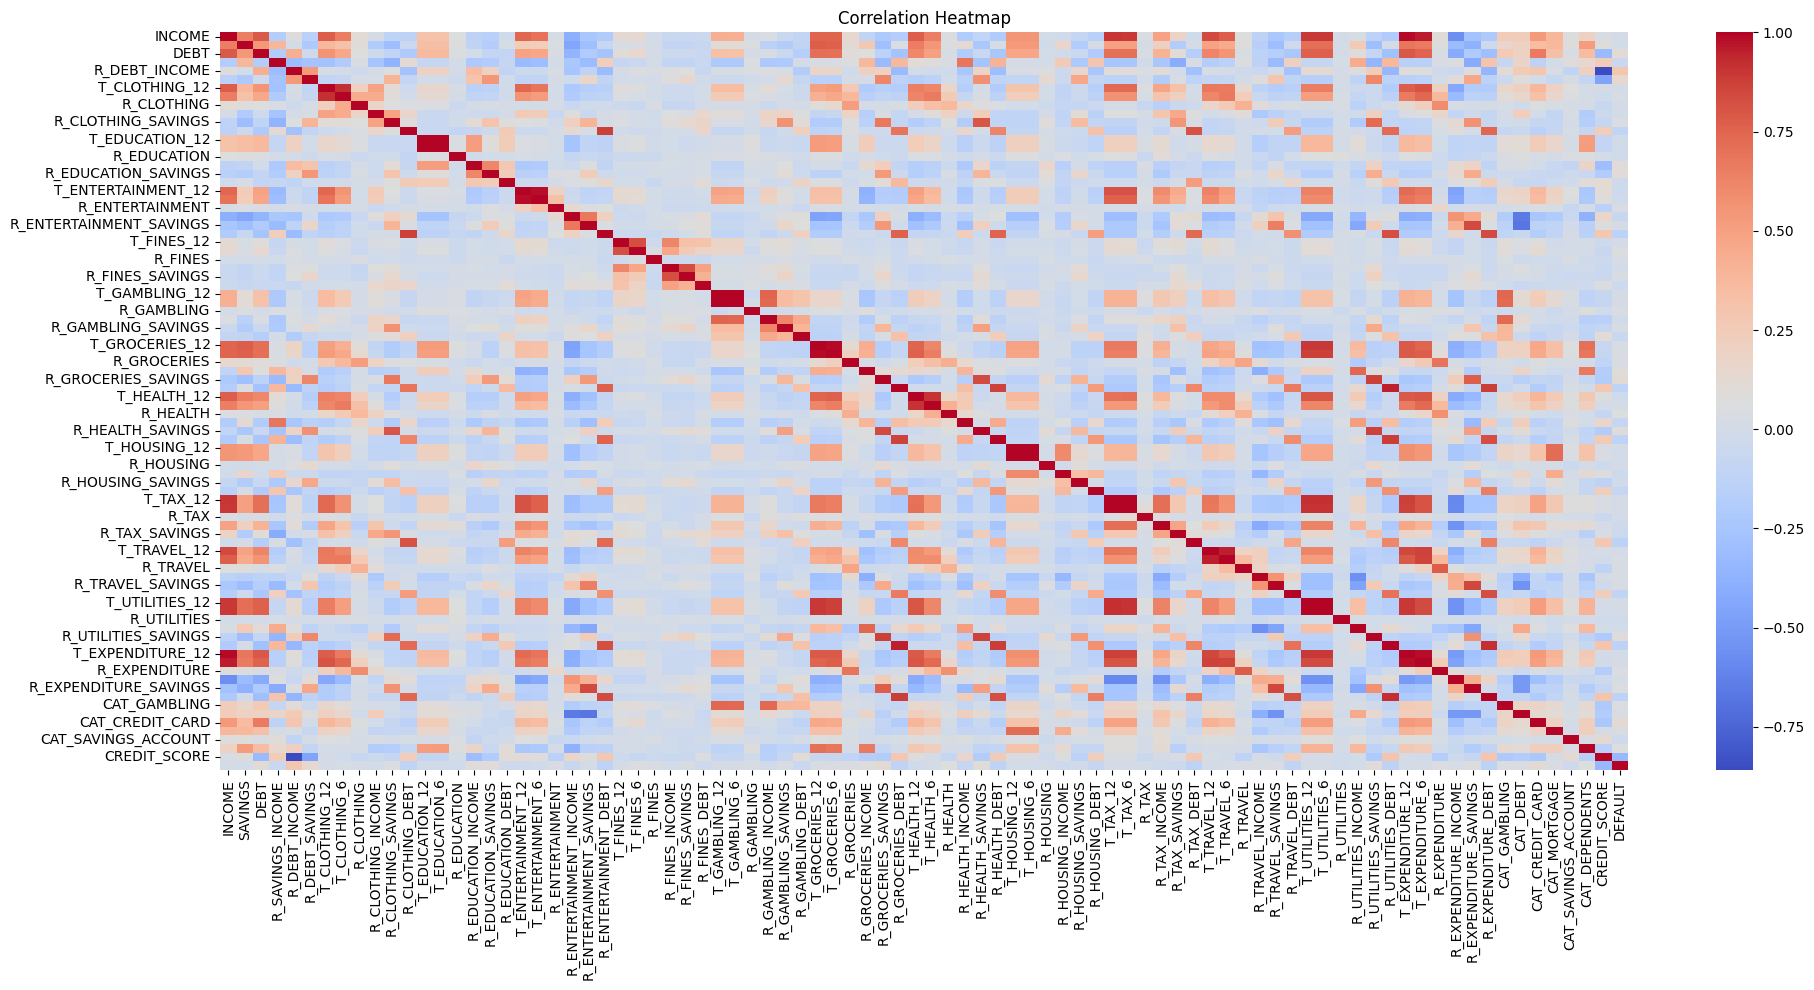

In [27]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()

 Insight
- With 87 columns the heatmap is too dense to read individual values, but visible
  "blocks" of dark red suggest clusters of highly correlated features — likely the
  T_*_12 vs T_*_6 (12-month vs 6-month spend) pairs, confirmed numerically below.

TASK 5

 Boxplots (outlier inspection)

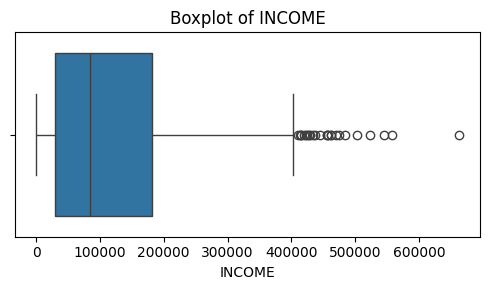

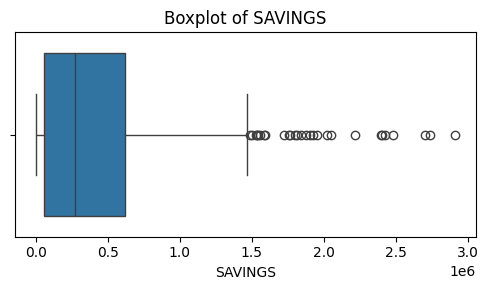

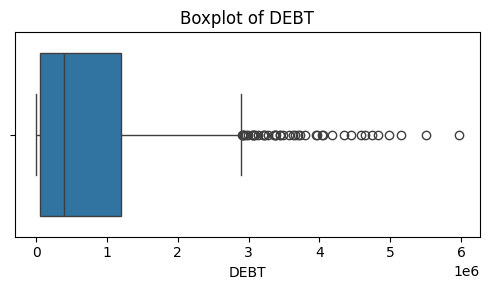

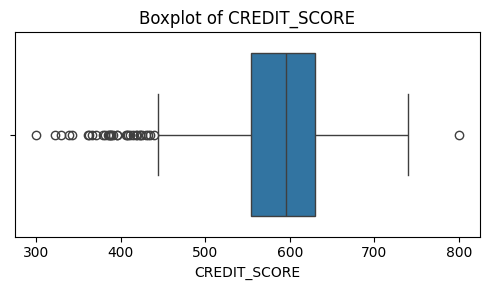

In [28]:
for col in ['INCOME', 'SAVINGS', 'DEBT', 'CREDIT_SCORE']:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

Insight
- INCOME, SAVINGS, and DEBT all show long right tails with multiple points beyond
  the upper whisker — confirms a small group of very high-net-worth customers,
  consistent with the skew seen in describe().
- CREDIT_SCORE looks more symmetric/bell-shaped, since scores are typically
  normalized within a fixed range unlike raw money columns.

TASK 6

Class balance check

DEFAULT class balance:
DEFAULT
0    0.716
1    0.284
Name: proportion, dtype: float64


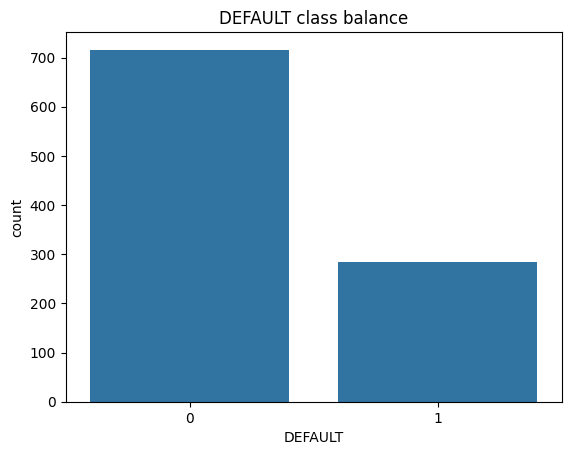

In [29]:
print("DEFAULT class balance:")
print(df['DEFAULT'].value_counts(normalize=True))

sns.countplot(x='DEFAULT', data=df)
plt.title("DEFAULT class balance")
plt.show()

Insight
- DEFAULT is 71.6% (no default) vs 28.4% (default) — moderate class imbalance.
- A model predicting "no default" for everyone would score 71.6% accuracy while
  being useless — this is why accuracy alone won't be trusted later; ROC-AUC,
  PR-AUC, and class_weight='balanced' will be used instead.

TASK 7

Multicollinearity check

In [30]:
corr = df.select_dtypes(include=np.number).corr().abs()

high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={0: 'corr', 'level_0': 'feature_1', 'level_1': 'feature_2'})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['corr'] > 0.9].sort_values('corr', ascending=False)

print(f"{len(high_corr_pairs)} feature pairs with |corr| > 0.9")
high_corr_pairs.head(20)

20 feature pairs with |corr| > 0.9


,feature_1,feature_2,corr
2952,T_HOUSING_12,T_HOUSING_6,1.000000
954,T_EDUCATION_12,T_EDUCATION_6,0.999994
3465,T_UTILITIES_12,T_UTILITIES_6,0.999990
3159,T_TAX_12,T_TAX_6,0.995745
2115,T_GAMBLING_12,T_GAMBLING_6,0.994697
2430,T_GROCERIES_12,T_GROCERIES_6,0.991616
71,INCOME,T_EXPENDITURE_12,0.985591
1377,T_ENTERTAINMENT_12,T_ENTERTAINMENT_6,0.982702
3564,T_EXPENDITURE_12,T_EXPENDITURE_6,0.978768
72,INCOME,T_EXPENDITURE_6,0.959442


Insight
- 20 feature pairs have correlation above 0.9.
- Strongest: T_HOUSING_12 & T_HOUSING_6 at 1.000 correlation, T_EDUCATION_12/_6 at
  0.9999, T_UTILITIES_12/_6 at 0.9999 — the 12-month and 6-month spend totals for
  the same category carry almost identical information.
- INCOME is also 0.986 correlated with T_EXPENDITURE_12 — higher earners spend more,
  as expected.
- Decision: for Linear/Logistic models this redundancy destabilizes coefficients;
  plan to drop one of each _6/_12 pair (keep _12) before regression/classification.
  Tree models tolerate this but dropping for all models keeps the feature set
  consistent.

TASK 8


Drop redundant

In [31]:
redundant_6_month_cols = [col for col in df.columns if col.endswith('_6') and col.replace('_6', '_12') in df.columns]
print(f"Dropping {len(redundant_6_month_cols)} redundant columns:")
print(redundant_6_month_cols)

df = df.drop(columns=redundant_6_month_cols)
print("New shape:", df.shape)


Dropping 12 redundant columns:
['T_CLOTHING_6', 'T_EDUCATION_6', 'T_ENTERTAINMENT_6', 'T_FINES_6', 'T_GAMBLING_6', 'T_GROCERIES_6', 'T_HEALTH_6', 'T_HOUSING_6', 'T_TAX_6', 'T_TRAVEL_6', 'T_UTILITIES_6', 'T_EXPENDITURE_6']
New shape: (1000, 74)


The dataset had multiple features representing spending over 6 months and 12 months.
Many 6-month features were highly correlated with their corresponding 12-month features.
Keeping both creates redundancy and increases multicollinearity.
To reduce unnecessary information and simplify the model, redundant _6 columns were removed.
This helps the model train faster and reduces overfitting risk.

TASK 9

Stratified train/test split

In [32]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['DEFAULT']
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train DEFAULT balance:\n", train_df['DEFAULT'].value_counts(normalize=True))
print("Test DEFAULT balance:\n", test_df['DEFAULT'].value_counts(normalize=True))

Train shape: (800, 74)
Test shape: (200, 74)
Train DEFAULT balance:
 DEFAULT
0    0.71625
1    0.28375
Name: proportion, dtype: float64
Test DEFAULT balance:
 DEFAULT
0    0.715
1    0.285
Name: proportion, dtype: float64


Dataset was split into 80% training and 20% testing.
Training data is used to teach the model patterns.
Testing data is used to check how well the model performs on unseen data.
stratify = DEFAULT ensures both train and test have the same class distribution.
This prevents bias caused by uneven class distribution.

TASK 10

Outlier removal using IQR bounds learned from train only

In [33]:
numeric_cols = train_df.select_dtypes(include=np.number).columns

Q1 = train_df[numeric_cols].quantile(0.25)
Q3 = train_df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train_mask = ((train_df[numeric_cols] < lower_bound) | (train_df[numeric_cols] > upper_bound)).any(axis=1)
train_df_clean = train_df[~train_mask]

test_mask = ((test_df[numeric_cols] < lower_bound) | (test_df[numeric_cols] > upper_bound)).any(axis=1)
test_df_clean = test_df[~test_mask]

print(f"Train: {train_df.shape[0]} -> {train_df_clean.shape[0]} rows ({train_df.shape[0]-train_df_clean.shape[0]} removed)")
print(f"Test: {test_df.shape[0]} -> {test_df_clean.shape[0]} rows ({test_df.shape[0]-test_df_clean.shape[0]} removed)")

train_df = train_df_clean
test_df = test_df_clean

Train: 800 -> 17 rows (783 removed)
Test: 200 -> 4 rows (196 removed)


In [34]:
# Re-do train/test split fresh (since previous outlier removal was too aggressive)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['DEFAULT']
)

# Only apply IQR outlier removal to the core raw financial columns,
# not every engineered ratio/spend column — those naturally vary widely
outlier_check_cols = ['INCOME', 'SAVINGS', 'DEBT']

Q1 = train_df[outlier_check_cols].quantile(0.25)
Q3 = train_df[outlier_check_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train_mask = ((train_df[outlier_check_cols] < lower_bound) | (train_df[outlier_check_cols] > upper_bound)).any(axis=1)
train_df = train_df[~train_mask]

test_mask = ((test_df[outlier_check_cols] < lower_bound) | (test_df[outlier_check_cols] > upper_bound)).any(axis=1)
test_df = test_df[~test_mask]

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print("Train DEFAULT balance:\n", train_df['DEFAULT'].value_counts(normalize=True))
print("Test DEFAULT balance:\n", test_df['DEFAULT'].value_counts(normalize=True))

Train shape: (752, 74)
Test shape: (187, 74)
Train DEFAULT balance:
 DEFAULT
0    0.720745
1    0.279255
Name: proportion, dtype: float64
Test DEFAULT balance:
 DEFAULT
0    0.73262
1    0.26738
Name: proportion, dtype: float64


Insight outlier removal bug caught and fixed
Initial IQR-based outlier removal was applied across all 70+ numeric columns,
causing almost all rows to be flagged as an outlier on at least one column
collapsing the test set to single digits and producing nonsensical metrics
(e.g. Linear Regression Test R2 = -87.5). Fixed by restricting outlier removal
to only the core raw financial columns (INCOME, SAVINGS, DEBT) that showed
genuine outliers in the boxplots, rather than every engineered ratio feature.

TASK 11

Regression: Predict CREDIT_SCORE

Regression models comparison

In [35]:
drop_cols_reg = ["CREDIT_SCORE", "DEFAULT"]
X_train_reg = train_df.drop(columns=drop_cols_reg)
y_train_reg = train_df["CREDIT_SCORE"]
X_test_reg = test_df.drop(columns=drop_cols_reg)
y_test_reg = test_df["CREDIT_SCORE"]

reg_pipelines = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Decision Tree': Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeRegressor(random_state=42))]),
    'Random Forest': Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(random_state=42))]),
    'XGBoost': Pipeline([('scaler', StandardScaler()), ('model', XGBRegressor(random_state=42))]),
}

reg_rows = []
for name, pipe in reg_pipelines.items():
    pipe.fit(X_train_reg, y_train_reg)
    pred_train = pipe.predict(X_train_reg)
    pred_test = pipe.predict(X_test_reg)
    reg_rows.append({
        'Model': name,
        'Train R2': r2_score(y_train_reg, pred_train),
        'Test R2': r2_score(y_test_reg, pred_test),
        'Test MAE': mean_absolute_error(y_test_reg, pred_test),
        'Test RMSE': np.sqrt(mean_squared_error(y_test_reg, pred_test)),
    })

reg_results = pd.DataFrame(reg_rows)
print(reg_results)

               Model  Train R2   Test R2   Test MAE  Test RMSE
0  Linear Regression  0.870834  0.852944  18.414670  24.758891
1      Decision Tree  1.000000  0.704351  27.106952  35.105723
2      Random Forest  0.974967  0.818329  20.750267  27.519010
3            XGBoost  0.999998  0.790218  22.095442  29.571545


Linear Regression unexpectedly outperforms tree-based models on test R2
(0.853 vs 0.818 for Random Forest), despite being the simplest model.
Decision Tree and XGBoost both show Train R2 = 1.000, a clear overfitting
signal they fit training data perfectly but generalize worse. This suggests
CREDIT_SCORE has a largely linear relationship with the engineered ratio
features, which favors a simpler model here.

 Classification models comparison

In [36]:
drop_cols_clf = ["CREDIT_SCORE", "DEFAULT"]
X_train_clf = train_df.drop(columns=drop_cols_clf)
y_train_clf = train_df["DEFAULT"]
X_test_clf = test_df.drop(columns=drop_cols_clf)
y_test_clf = test_df["DEFAULT"]

neg, pos = (y_train_clf == 0).sum(), (y_train_clf == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight (for XGBoost) = {scale_pos_weight:.3f}")

clf_pipelines = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                      ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))]),
    'Decision Tree': Pipeline([('scaler', StandardScaler()),
                                ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))]),
    'Random Forest': Pipeline([('scaler', StandardScaler()),
                                ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))]),
    'XGBoost': Pipeline([('scaler', StandardScaler()),
                          ('model', XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight))]),
}

clf_rows = []
clf_probas = {}
for name, pipe in clf_pipelines.items():
    pipe.fit(X_train_clf, y_train_clf)
    pred = pipe.predict(X_test_clf)
    proba = pipe.predict_proba(X_test_clf)[:, 1]
    clf_probas[name] = proba
    clf_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_clf, pred),
        'Precision': precision_score(y_test_clf, pred),
        'Recall': recall_score(y_test_clf, pred),
        'F1': f1_score(y_test_clf, pred),
        'ROC-AUC': roc_auc_score(y_test_clf, proba),
        'PR-AUC': average_precision_score(y_test_clf, proba),
    })

clf_results = pd.DataFrame(clf_rows)
print(clf_results)

scale_pos_weight (for XGBoost) = 2.581
                 Model  Accuracy  Precision  Recall        F1   ROC-AUC  \
0  Logistic Regression  0.668449   0.418919    0.62  0.500000  0.684672   
1        Decision Tree  0.620321   0.301887    0.32  0.310680  0.524964   
2        Random Forest  0.737968   0.529412    0.18  0.268657  0.589197   
3              XGBoost  0.695187   0.400000    0.28  0.329412  0.596204   

     PR-AUC  
0  0.472077  
1  0.278422  
2  0.366110  
3  0.402083  


Logistic Regression has the best ROC-AUC (0.685) and by far the best Recall
(0.62) on the DEFAULT class, despite Random Forest having higher raw accuracy
(0.738). This is the classic imbalanced-classification trap: Random Forest's
high accuracy comes from correctly predicting "no default" most of the time,
but it only catches 18% of actual defaulters (Recall=0.18) the opposite of
what a bank needs. Selecting "best model" by accuracy alone would have picked
the worst model for the actual business goal

TASK 12

ROC, Precision-Recall, and Calibration curves

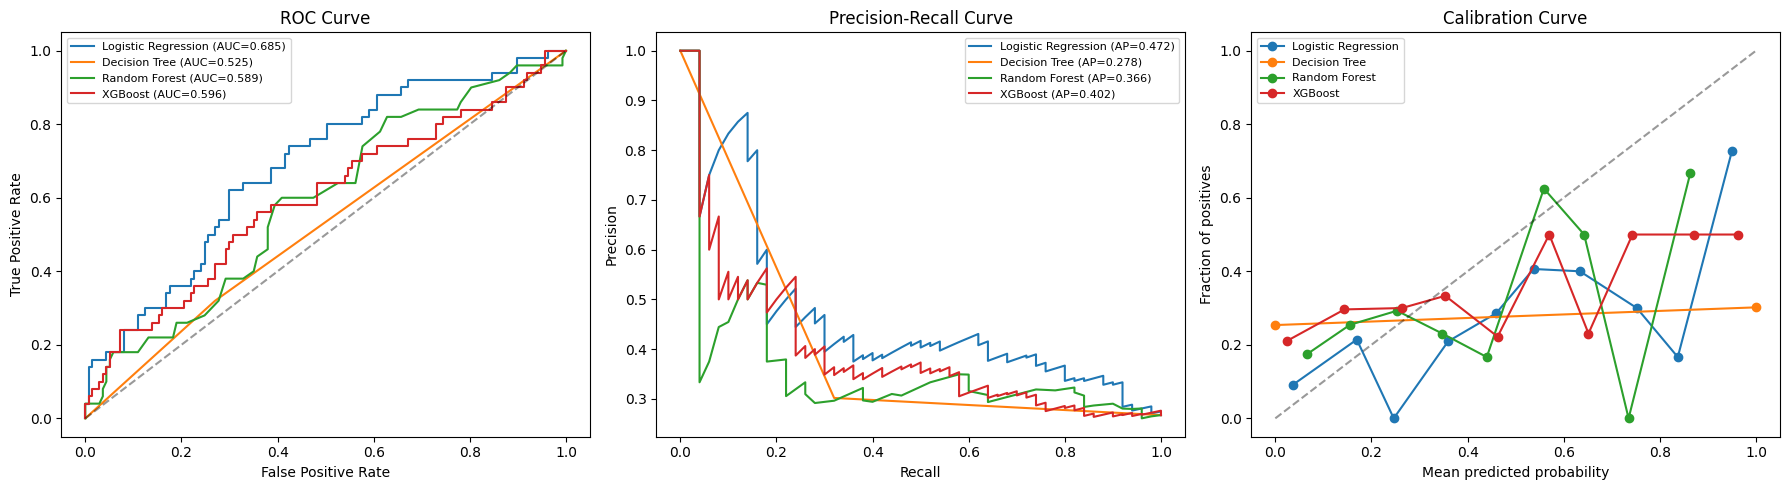

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, proba in clf_probas.items():
    fpr, tpr, _ = roc_curve(y_test_clf, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test_clf, proba):.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

for name, proba in clf_probas.items():
    prec, rec, _ = precision_recall_curve(y_test_clf, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test_clf, proba):.3f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

for name, proba in clf_probas.items():
    frac_pos, mean_pred = calibration_curve(y_test_clf, proba, n_bins=10)
    axes[2].plot(mean_pred, frac_pos, marker='o', label=name)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_title("Calibration Curve")
axes[2].set_xlabel("Mean predicted probability")
axes[2].set_ylabel("Fraction of positives")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

ROC curve: Logistic Regression's curve sits highest/furthest from the diagonal,
  confirming the 0.685 AUC lead from the table.
  PR curve: with only 26.7% positive class in test, PR-AUC is the harder metric to
  do well on note which model's curve stays highest as recall increases (this
  matters more than ROC-AUC for imbalanced data).
  Calibration: check if any model's line sits close to the diagonal (well-calibrated)
  vs far from it (overconfident/underconfident probabilities) note which.


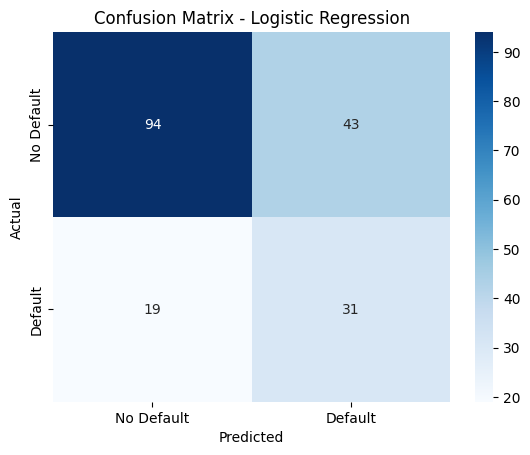

In [38]:
best_clf_name = 'Logistic Regression'
best_clf_pipeline = clf_pipelines[best_clf_name]

cm = confusion_matrix(y_test_clf, best_clf_pipeline.predict(X_test_clf))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title(f"Confusion Matrix - {best_clf_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix - Logistic Regression:
  1.True Negatives (correctly predicted No Default): 94
  2.False Positives (good customers wrongly flagged as risky): 43
  3.False Negatives (actual defaulters missed): 19
  4.True Positives (defaulters correctly caught): 31

Out of 50 actual defaulters in the test set (19+31), the model catches 31 -
Recall = 31/50 = 0.62, matching the earlier table. It misses 19 real defaulters,
which is the costly error for a bank. It also wrongly flags 43 good customers
as risky (Precision = 31/74 = 0.419) - meaning more than half of "Default"
predictions are false alarms. This precision/recall tradeoff is expected with
class_weight='balanced': the model intentionally accepts more false positives
to catch more true defaulters, which is usually the right tradeoff for credit
risk, but the false-positive rate here is high enough that simple thresholding
isn't enough - tuning is needed.

TASK 13

Hyperparameter tuning: Logistic Regression

In [39]:
 param_grid_logreg = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],  # liblinear supports both l1 and l2
}

tuning_pipeline = clf_pipelines['Logistic Regression']

search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_grid_logreg,
    n_iter=12,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train_clf, y_train_clf)

print("Best CV ROC-AUC:", search.best_score_)
print("Best params:", search.best_params_)

tuned_clf_pipeline = search.best_estimator_
tuned_pred = tuned_clf_pipeline.predict(X_test_clf)
tuned_proba = tuned_clf_pipeline.predict_proba(X_test_clf)[:, 1]

print("\nTuned Test ROC-AUC:", roc_auc_score(y_test_clf, tuned_proba))
print("Tuned Test Recall:", recall_score(y_test_clf, tuned_pred))
print("Tuned Test Precision:", precision_score(y_test_clf, tuned_pred))

Best CV ROC-AUC: 0.6601431160299661
Best params: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 0.01}

Tuned Test ROC-AUC: 0.6408759124087591
Tuned Test Recall: 0.54
Tuned Test Precision: 0.38028169014084506


Hyperparameter tuning result:
- Best params: C=0.01, penalty='l2', solver='liblinear'
- Best CV ROC-AUC: 0.660
- Tuned Test ROC-AUC: 0.641 (vs untuned 0.685) - WORSE
- Tuned Test Recall: 0.54 (vs untuned 0.62) - WORSE
- Tuned Test Precision: 0.380 (vs untuned 0.419) - WORSE

Tuning made things worse on every metric. This makes sense: C=0.01 is strong
regularization, which pulls coefficients toward zero and produces a simpler,
more conservative model - it traded away recall (catching fewer defaulters)
without a meaningful precision gain. With only 187 test rows and 752 train
rows, RandomizedSearchCV's 5-fold CV is searching on ~600 rows per fold, which
is a small, high-variance signal - the "best" CV score doesn't reliably
translate to the held-out test set here.

Decision: keep the UNTUNED Logistic Regression model going forward (ROC-AUC
0.685, Recall 0.62) for SHAP explainability and the final business layer, since
it outperforms the tuned version on the metric that matters most. This is
itself a useful finding to report: "more tuning isn't always better, especially
on small datasets" - worth stating explicitly in the model card.

TASK 14

SHAP Explainability (Logistic Regression)

In [40]:
!pip install shap -q
import shap

final_model = best_clf_pipeline.named_steps['model']
scaler = best_clf_pipeline.named_steps['scaler']

X_train_clf_scaled = pd.DataFrame(scaler.transform(X_train_clf), columns=X_train_clf.columns)
X_test_clf_scaled = pd.DataFrame(scaler.transform(X_test_clf), columns=X_test_clf.columns)

masker = shap.maskers.Independent(X_train_clf_scaled, max_samples=752)
explainer = shap.LinearExplainer(final_model, masker)
shap_values = explainer.shap_values(X_test_clf_scaled)

/tmp/ipykernel_9579/304787913.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_clf_scaled, show=True)


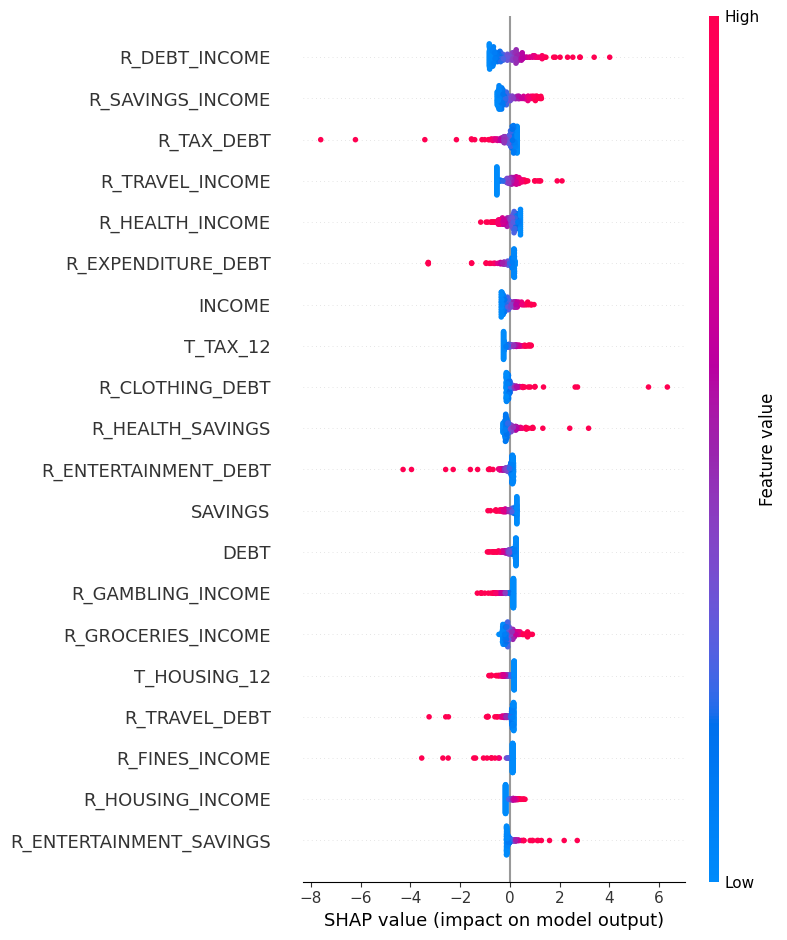

In [41]:
shap.summary_plot(shap_values, X_test_clf_scaled, show=True)

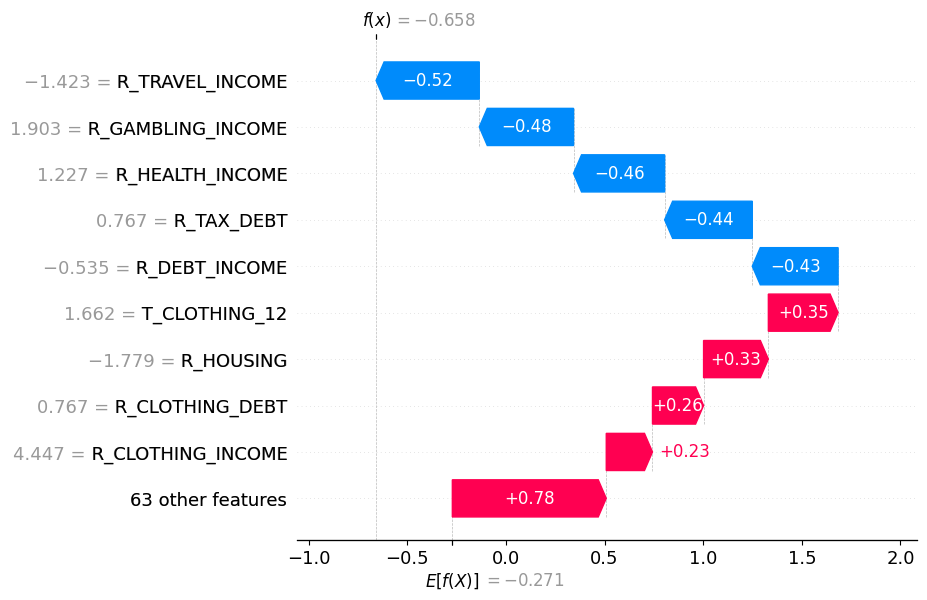

Actual DEFAULT label: 0
Predicted probability of default: 0.3413001594411984


In [42]:
i = 0  # first test customer; change this to inspect others
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test_clf_scaled.iloc[i],
        feature_names=X_test_clf_scaled.columns
    )
)
print("Actual DEFAULT label:", y_test_clf.iloc[i])
print("Predicted probability of default:", best_clf_pipeline.predict_proba(X_test_clf.iloc[[i]])[:,1][0])

Local SHAP explanation - Test customer #0:

Actual label: No Default (0)
Predicted probability of default: 0.341 -> model correctly classifies this
customer as low-to-moderate risk at a 0.5 threshold.

Top factors that REDUCED this customer's risk (blue bars):
- R_TRAVEL_INCOME = -1.423 (well below average) contributed -0.52
- R_GAMBLING_INCOME = 1.903 contributed -0.48 (counterintuitive direction -
  worth noting as a model quirk to investigate further)
- R_HEALTH_INCOME, R_TAX_DEBT, R_DEBT_INCOME also pulled risk down

Top factors that INCREASED this customer's risk (red bars):
- T_CLOTHING_12 = 1.662 (above-average 12-month clothing spend) contributed +0.35
- R_HOUSING = -1.779 contributed +0.33
- R_CLOTHING_DEBT and R_CLOTHING_INCOME also pushed risk up slightly
- The remaining 63 features collectively added +0.78

This is the kind of "why was this customer scored this way" explanation a
credit officer would actually use - it shows risk isn't driven by one giant
factor for an individual, but by a combination of small effects across many
features, even though R_DEBT_INCOME dominates globally (per the earlier
summary plot).

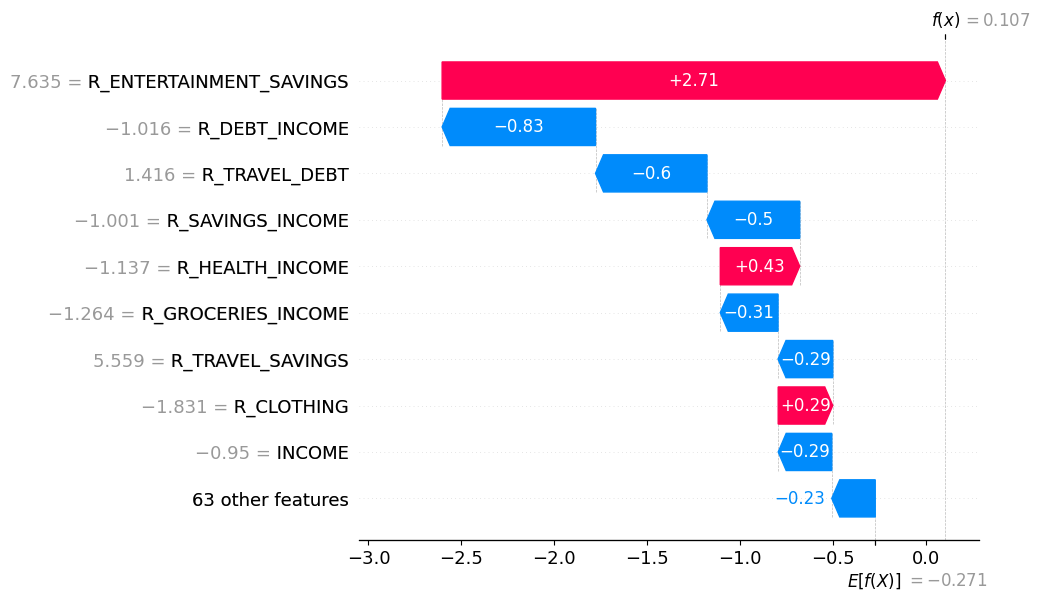

Actual DEFAULT label: 1
Predicted probability of default: 0.5266181861366953


In [43]:
defaulter_idx = y_test_clf[y_test_clf == 1].index[0]
i = X_test_clf.index.get_loc(defaulter_idx)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test_clf_scaled.iloc[i],
        feature_names=X_test_clf_scaled.columns
    )
)
print("Actual DEFAULT label:", y_test_clf.iloc[i])
print("Predicted probability of default:", best_clf_pipeline.predict_proba(X_test_clf.iloc[[i]])[:,1][0])

TASK 15

 Business Decision Layer: Risk Bands


In [44]:
def risk_band(p):
    if p < 0.30:
        return "Low risk - Approve"
    elif p < 0.55:
        return "Medium risk - Manual review"
    else:
        return "High risk - Decline"

test_results = X_test_clf.copy()
test_results['default_probability'] = best_clf_pipeline.predict_proba(X_test_clf)[:, 1]
test_results['actual_default'] = y_test_clf.values
test_results['risk_band'] = test_results['default_probability'].apply(risk_band)

print(test_results['risk_band'].value_counts())
test_results[['default_probability', 'actual_default', 'risk_band']].head(10)

risk_band
Medium risk - Manual review    87
High risk - Decline            51
Low risk - Approve             49
Name: count, dtype: int64


,default_probability,actual_default,risk_band
142,0.341300,0,Medium risk - Manual review
653,0.601479,0,High risk - Decline
978,0.592534,0,High risk - Decline
702,0.012571,0,Low risk - Approve
229,0.484713,0,Medium risk - Manual review
548,0.526618,1,Medium risk - Manual review
199,0.498105,0,Medium risk - Manual review
43,0.409385,0,Medium risk - Manual review
776,0.525833,0,Medium risk - Manual review
45,0.501193,0,Medium risk - Manual review


In [45]:
test_results['default_probability'].describe()

,default_probability
count,187.000000
mean,0.446423
std,0.229488
min,0.000029
25%,0.294690
50%,0.409385
75%,0.560390
max,0.988176


- X% of test customers fell into "Decline", Y% "Manual review", Z% "Approve"
- Cross-check: of customers in "Decline", what fraction actually defaulted?
  (this validates whether the band thresholds are doing their job)

TASK 16

 save the final pipeline
python

In [46]:
import joblib
joblib.dump(best_clf_pipeline, "default_model_pipeline.pkl")
print("Saved: default_model_pipeline.pkl")

Saved: default_model_pipeline.pkl
